## Assignment 6 - Deadline: April 15, 2026, Wed 11pm

#### DSAI 541 Spring 2026

Complete the assignment below and upload <span style="color:red">both the .ipynb file and its pdf</span> to https://moodle.bogazici.edu.tr by the deadline given above. The submission page on Moodle will close automatically after this date and time and no late homeworks will be accepted.


To make a pdf, this may work if you're using Jupyter notebook on browser: Hit CMD+P or CTRL+P, and save it as PDF. You may also use other options from the File menu. (You can use Google Colab, but at the end you should download the ipynb notebook to submit it on Moodle.)

In [2]:
# Run this cell first

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import HTML
from sklearn.model_selection import train_test_split

# Set the display option to show all rows scrolling with a slider
pd.set_option('display.max_rows', None)
# To disable this, run the line below:
# pd.reset_option('display.max_rows')

# Problem 1: LSTM with Jena weather dataset (60 pts)

(You can use Tensorflow or PyTorch in this assignment.)

We will forecast temperature using past temperature data, where the data is resampled hourly (unlike in class, where we used two-hour intervals).

**Part a)** Load the Jena weather dataset. Do data cleaning (filling missing values, interpolation etc) just as we did in class (Lecture 10). Then, generate `data_1H`, where the data points are spaced 1 hour apart (in class, we had generated  `data_2H`). The sequence length should cover past 6 days, so modify `sequence_length` accordingly.

**Part b)** Train an LSTM model as we did in class by using only the "T (degC)" column to predict the next temperature value. Make sure you use early stopping. Plot your train and validation curves. Also report MSE, MAE and MAPE on the test set.

**Part c)** Use the data from the latest part from the train set to predict next 100 data points via recursive forecasting as we did in class. Make a plot similar to the below. (Here using the code from Lecture 10 notebook may be easier than using ChatGPT.)

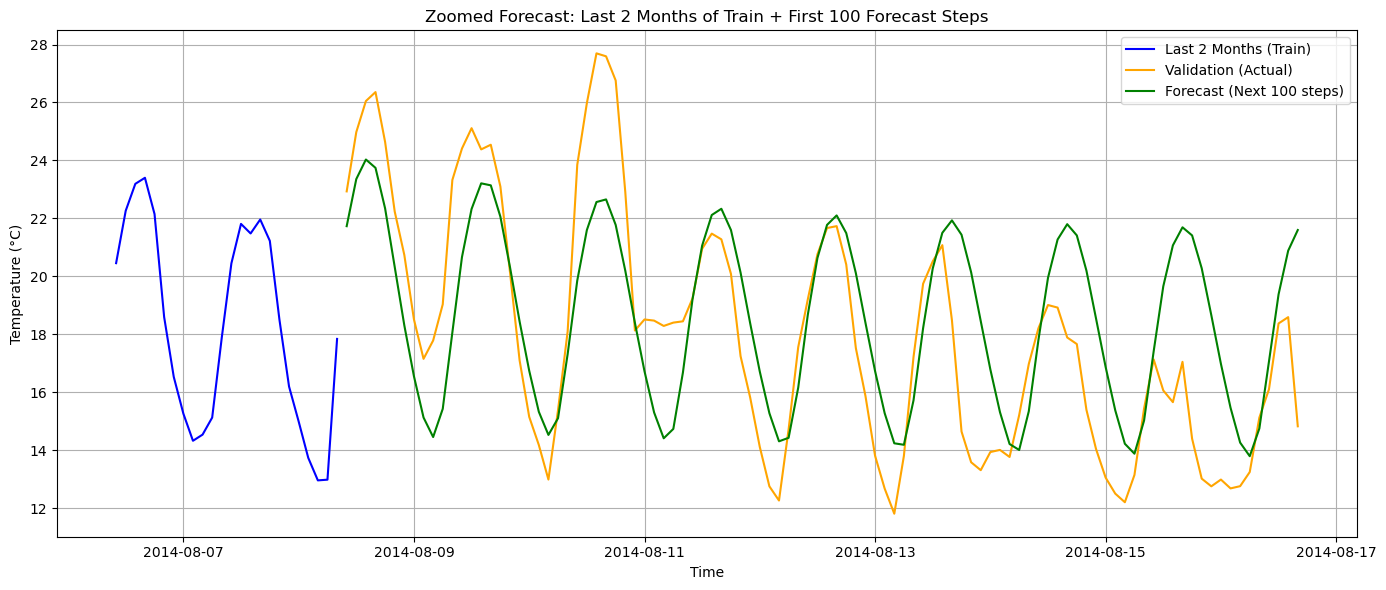

**Part d)** Repeat all steps, but use a slightly different model (different amount of LSTM neurons, layers and/or dropout) and make the plot again as in Part c). 

#### Import of necessery libraries and other stuffs

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
from sklearn.preprocessing import StandardScaler
import copy

#### Part A)

In [ ]:
data = pd.read_csv('../datasets/jena_climate_2009_2016.csv')
data['Date Time'] = pd.to_datetime(data['Date Time'], format='%d.%m.%Y %H:%M:%S')


data.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [6]:
data.sort_values(by='Date Time', inplace=True)

In [7]:
duplicates = data['Date Time'].duplicated(keep=False) # gives True or False for all rows.
data[duplicates].head() # print the rows for the indices where duplicate is True.

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
78766,2010-07-01 00:10:00,992.06,17.87,291.69,14.06,78.4,20.50,16.07,4.43,10.14,16.20,1180.21,0.31,0.56,51.11
78622,2010-07-01 00:10:00,992.06,17.87,291.69,14.06,78.4,20.50,16.07,4.43,10.14,16.20,1180.21,0.31,0.56,51.11
78623,2010-07-01 00:20:00,992.02,17.82,291.65,14.03,78.5,20.44,16.04,4.39,10.12,16.17,1180.38,0.23,0.48,52.64
78767,2010-07-01 00:20:00,992.02,17.82,291.65,14.03,78.5,20.44,16.04,4.39,10.12,16.17,1180.38,0.23,0.48,52.64
78624,2010-07-01 00:30:00,992.04,17.92,291.75,14.09,78.3,20.57,16.10,4.46,10.16,16.23,1179.97,0.18,0.40,22.10


In [8]:
data = data.drop_duplicates(subset='Date Time', keep='first')
data = data.reset_index(drop=True)

In [9]:
gaps = data['Date Time'].diff() != pd.Timedelta(minutes=10)
skips = data[gaps]

print(f"Number of skips: {skips.shape[0]}")
print("Rows after skips (showing next entries after each gap):")
print(skips['Date Time'].head())


Number of skips: 7
Rows after skips (showing next entries after each gap):
0        2009-01-01 00:10:00
40378    2009-10-08 10:10:00
229875   2013-05-16 09:10:00
293229   2014-07-30 08:20:00
301346   2014-09-25 09:00:00
Name: Date Time, dtype: datetime64[ns]


In [10]:
# 1. Set Date Time as index (if not already)
data = data.set_index('Date Time')

# 2. Create a complete datetime index with 10-minute frequency
full_index = pd.date_range(start=data.index.min(), end=data.index.max(), freq='10min') # 10T means 10 min

# 3. Reindex the dataframe to include missing times
data = data.reindex(full_index)

# 4. Interpolate linearly
data = data.interpolate(method='linear')

# 5. (Optional) Reset index and rename it back
data = data.reset_index().rename(columns={'index': 'Date Time'})

In [11]:
# Check if there are gaps
gaps = data['Date Time'].diff() != pd.Timedelta(minutes=10)
skips = data[gaps]

print(f"Number of skips: {skips.shape[0]}")
print("Rows after skips (showing next entries after each gap):")
print(skips['Date Time'].head())


Number of skips: 1
Rows after skips (showing next entries after each gap):
0   2009-01-01 00:10:00
Name: Date Time, dtype: datetime64[ns]


In [12]:
data.isna().sum()

Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

In [13]:

data = data.set_index('Date Time')
data_1H = data.resample('1h').mean()

data_1H.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,174.460000
2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,0.316667,0.711667,172.416667
2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,0.248333,0.606667,196.816667
2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,0.176667,0.606667,157.083333
2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,0.290000,0.670000,150.093333


##### Setting Dataloaders and Sequence generation

In [14]:
# Prepare data
target_data = data_1H[['T (degC)']].copy()  # don't overwrite 'data'
target_data = target_data.dropna()

# Split data (70% train, 20% val, 10% test)
n = len(target_data)
train_df = target_data[:int(n * 0.7)]
val_df = target_data[int(n * 0.7):int(n * 0.9)]
test_df = target_data[int(n * 0.9):]

# Scale data
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

In [15]:
# Sequence generator
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

sequence_length = 24*6  # using past 6 days (24 hours * 6) to predict next hour
X_train, y_train = create_sequences(train_scaled, sequence_length)
X_val, y_val = create_sequences(val_scaled, sequence_length)
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Reshape for LSTM
X_train = X_train.reshape(-1, sequence_length, 1)
X_val = X_val.reshape(-1, sequence_length, 1)
X_test = X_test.reshape(-1, sequence_length, 1)

In [16]:
print("First five temperature in sequence 1")
print(X_train[0,0:5]) 
print()
print("First five temperature in sequence 2")
print(X_train[1,0:5])

First five temperature in sequence 1
[[-2.01429683]
 [-1.98665073]
 [-2.06742977]
 [-2.08285298]
 [-2.13509908]]

First five temperature in sequence 2
[[-1.98665073]
 [-2.06742977]
 [-2.08285298]
 [-2.13509908]
 [-2.17770569]]


In [17]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#### Part B)

In [18]:
class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        
        self.lstm1 = nn.LSTM(input_size=1, hidden_size=64, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)


        self.lstm2 = nn.LSTM(input_size=64, hidden_size=32, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)

        self.dense = nn.Linear(32, 1)

    def forward(self, x):
        out, _ =  self.lstm1(x)
        out = self.dropout1(out)

        out, _ = self.lstm2(out)
        out = self.dropout2(out)

        out = self.dense(out[:, -1, :])  # take the last time step
        return out

In [19]:
def train_model(model, train_loader, val_loader, optimizer, criterion, scheduler=None, num_epochs=100):
    best_val_loss = float("inf")
    delta = 1e-5
    best_model = copy.deepcopy(model.state_dict())
    last_improvement_epoch = 0

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        run_epoch_train_loss = 0
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits , y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            run_epoch_train_loss += loss.item()

        avg_train_loss = run_epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}", end='')

        # Validation phase
        model.eval()
        run_epoch_val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device) # Reshape to (batch_size, 1)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                run_epoch_val_loss += loss.item()

        avg_val_loss = run_epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f", Validation Loss: {avg_val_loss:.4f}")
        
        if scheduler is not None:
            scheduler.step(avg_val_loss)

        # Early stopping based on validation loss
        if avg_val_loss < best_val_loss - delta:
            best_val_loss = avg_val_loss
            best_model = copy.deepcopy(model.state_dict())
            last_improvement_epoch = epoch
        elif epoch - last_improvement_epoch >= 15: # Stop if no improvement for 15 epochs
            print(f"Early stopping at epoch {epoch+1} with best validation loss: {best_val_loss:.4f}")
            break

    return train_losses, val_losses, best_val_loss, best_model, last_improvement_epoch

In [20]:
model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [21]:
t_l, v_l, b_v_l, b_m, l_i_e = train_model(model, train_loader, val_loader, optimizer, criterion, scheduler, num_epochs=40)

Epoch 1/40, Train Loss: 0.0724, Validation Loss: 0.0087
Epoch 2/40, Train Loss: 0.0196, Validation Loss: 0.0066
Epoch 3/40, Train Loss: 0.0170, Validation Loss: 0.0056
Epoch 4/40, Train Loss: 0.0160, Validation Loss: 0.0050
Epoch 5/40, Train Loss: 0.0156, Validation Loss: 0.0049
Epoch 6/40, Train Loss: 0.0156, Validation Loss: 0.0077
Epoch 7/40, Train Loss: 0.0153, Validation Loss: 0.0053
Epoch 8/40, Train Loss: 0.0152, Validation Loss: 0.0060
Epoch 9/40, Train Loss: 0.0152, Validation Loss: 0.0051
Epoch 10/40, Train Loss: 0.0148, Validation Loss: 0.0050
Epoch 11/40, Train Loss: 0.0147, Validation Loss: 0.0051
Epoch 12/40, Train Loss: 0.0139, Validation Loss: 0.0049
Epoch 13/40, Train Loss: 0.0142, Validation Loss: 0.0050
Epoch 14/40, Train Loss: 0.0139, Validation Loss: 0.0049
Epoch 15/40, Train Loss: 0.0138, Validation Loss: 0.0049
Epoch 16/40, Train Loss: 0.0142, Validation Loss: 0.0058
Epoch 17/40, Train Loss: 0.0140, Validation Loss: 0.0049
Epoch 18/40, Train Loss: 0.0138, Validat

In [22]:
model = LSTMModel().to(device)
model.load_state_dict(b_m)

<All keys matched successfully>

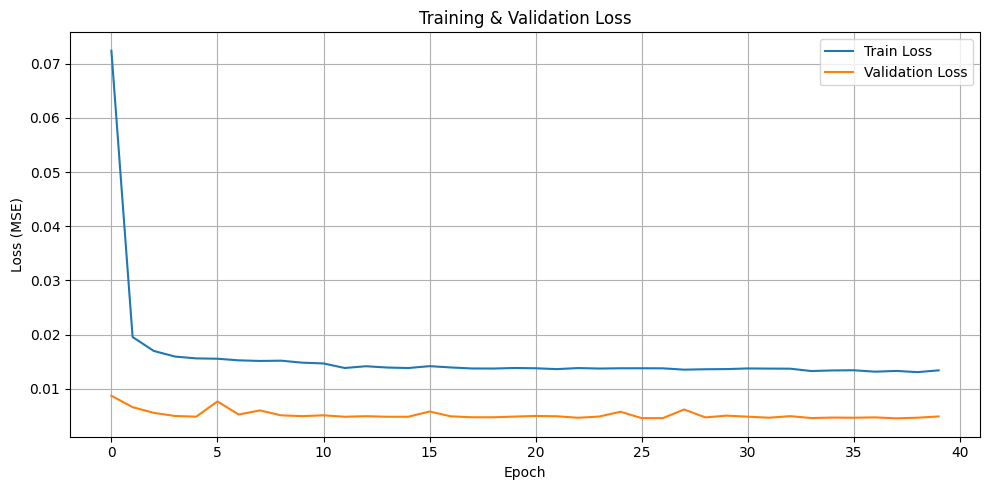

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(t_l, label='Train Loss')
plt.plot(v_l, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

with torch.no_grad():
    model.eval()
    y_pred_test = model(X_test_tensor.to(device)).cpu().numpy()
    y_test_np = y_test_tensor.cpu().numpy()
    y_pred_test_inv = scaler.inverse_transform(y_pred_test)
    y_test_inv = scaler.inverse_transform(y_test)
mse = mean_squared_error(y_test_inv, y_pred_test_inv)
mae = mean_absolute_error(y_test_inv, y_pred_test_inv)
mape = mean_absolute_percentage_error(y_test_inv, y_pred_test_inv)
print(f"Test MSE: {mse:.2f}, MAE: {mae:.2f},MAPE: {mape:.2%}")


Test MSE: 0.33, MAE: 0.40,MAPE: 10.73%


##### Part C)

In [25]:
# Forecast the next 100 Values
n_forecast = 100
model.eval()
last_sequence = train_scaled[-sequence_length:].reshape(1, sequence_length, 1)
forecast_scaled = []

for _ in range(n_forecast):
    next_pred = model(torch.tensor(last_sequence, dtype=torch.float32).to(device)).cpu().detach().numpy()
    forecast_scaled.append(next_pred[0, 0])
    last_sequence = np.append(last_sequence[:, 1:, :], [[[next_pred[0, 0]]]], axis=1)


# Inverse scale forecast
forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1))

# Build forecast time index
forecast_index = val_df.index[:n_forecast]

C:\Users\baldi\AppData\Local\Temp\ipykernel_3096\1818456642.py:2: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  last_2_months = train_df.last('60D')  # or '2M' for full calendar months


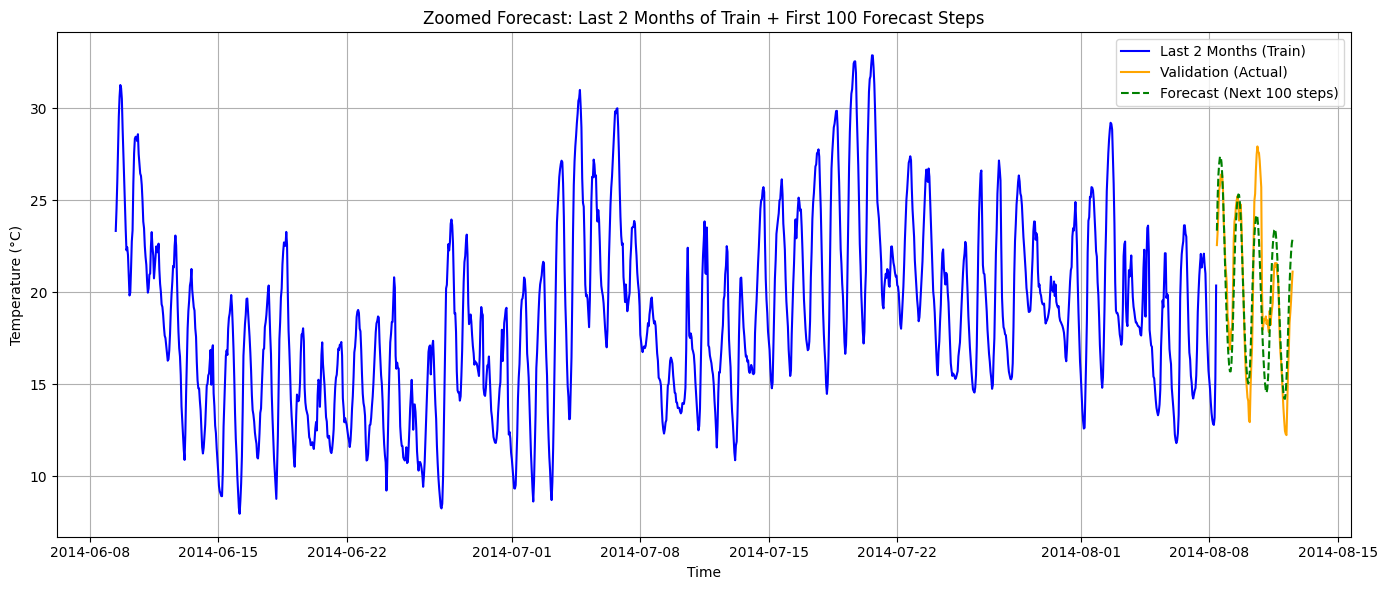

In [32]:
# Slice last 2 months of training data
last_2_months = train_df.last('60D')  # or '2M' for full calendar months

# First 100 validation actuals
val_plot = val_df.iloc[:n_forecast]

# Plot
plt.figure(figsize=(14, 6))
plt.plot(last_2_months.index, last_2_months['T (degC)'], label='Last 2 Months (Train)', color='blue')
plt.plot(val_plot.index, val_plot['T (degC)'], color='orange', label='Validation (Actual)')
plt.plot(forecast_index, forecast, label='Forecast (Next 100 steps)', color='green',linestyle='--')

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Zoomed Forecast: Last 2 Months of Train + First 100 Forecast Steps")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\baldi\AppData\Local\Temp\ipykernel_3096\1151203900.py:1: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  last_2_days = train_df.last('2D')


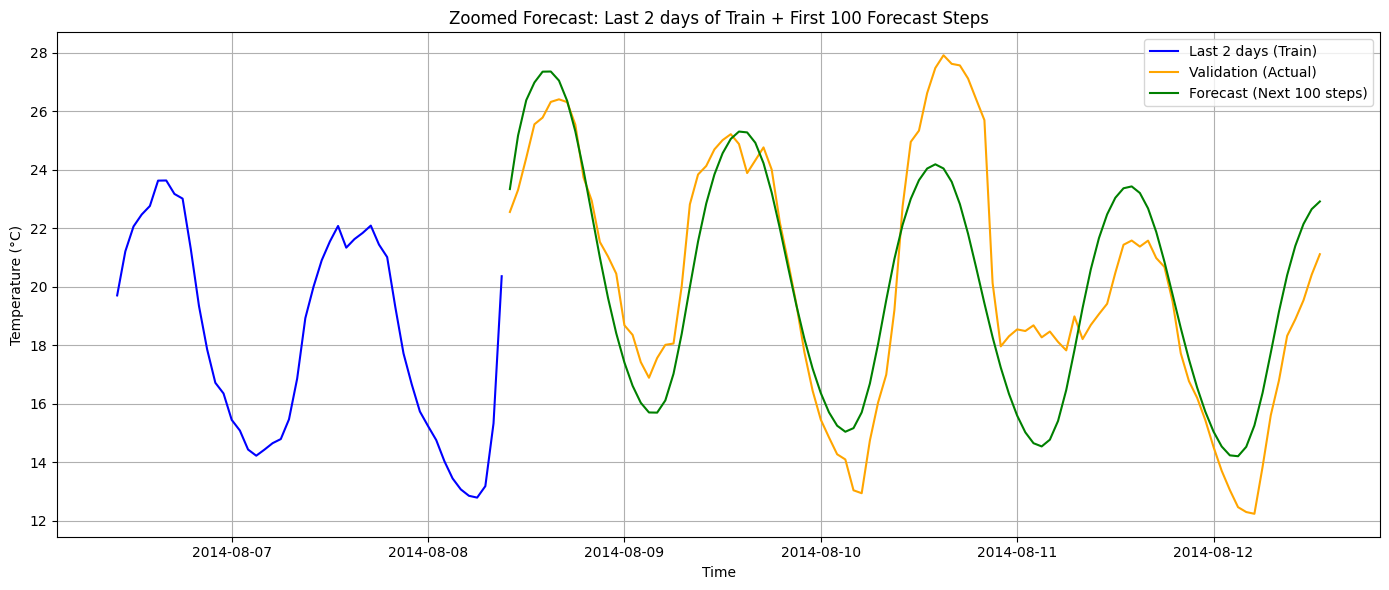

In [33]:
last_2_days = train_df.last('2D')  

# First 100 validation actuals
val_plot = val_df.iloc[:n_forecast]

# Plot
plt.figure(figsize=(14, 6))
plt.plot(last_2_days.index, last_2_days['T (degC)'], label='Last 2 days (Train)', color='blue')
plt.plot(val_plot.index, val_plot['T (degC)'], color='orange', label='Validation (Actual)')
plt.plot(forecast_index, forecast, label='Forecast (Next 100 steps)', color='green')

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Zoomed Forecast: Last 2 days of Train + First 100 Forecast Steps")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Part d)

In [28]:
class LSTMModel2(nn.Module):
    def __init__(self):
        super(LSTMModel2, self).__init__()
        
        self.lstm1 = nn.LSTM(input_size=1, hidden_size=128, batch_first=True)
        self.dropout1 = nn.Dropout(0.3)


        self.lstm2 = nn.LSTM(input_size=128, hidden_size=64, batch_first=True)
        self.dropout2 = nn.Dropout(0.3)

        self.lstm3 = nn.LSTM(input_size=64, hidden_size=64, batch_first=True)
        self.dropout3 = nn.Dropout(0.3)

        self.dense = nn.Linear(64, 1)

    def forward(self, x):
        out, _ =  self.lstm1(x)
        out = self.dropout1(out)

        out, _ = self.lstm2(out)
        out = self.dropout2(out)

        out, _ = self.lstm3(out)
        out = self.dropout3(out)

        out = self.dense(out[:, -1, :])  # take the last time step
        return out

In [29]:
model2 = LSTMModel2().to(device)
optimizer2 = optim.AdamW(model2.parameters(), lr=0.001, weight_decay=
1e-5)
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode='min', factor=0.5, patience=5)

##### Model Training)

In [30]:
t_l2, v_l2, b_v_l2, b_m2, l_i_e2 = train_model(model2, train_loader, val_loader, optimizer2, criterion, scheduler2, num_epochs=60)

Epoch 1/60, Train Loss: 0.0676, Validation Loss: 0.0071
Epoch 2/60, Train Loss: 0.0188, Validation Loss: 0.0080
Epoch 3/60, Train Loss: 0.0170, Validation Loss: 0.0052
Epoch 4/60, Train Loss: 0.0157, Validation Loss: 0.0059
Epoch 5/60, Train Loss: 0.0157, Validation Loss: 0.0059
Epoch 6/60, Train Loss: 0.0155, Validation Loss: 0.0052
Epoch 7/60, Train Loss: 0.0156, Validation Loss: 0.0055
Epoch 8/60, Train Loss: 0.0151, Validation Loss: 0.0056
Epoch 9/60, Train Loss: 0.0148, Validation Loss: 0.0052
Epoch 10/60, Train Loss: 0.0149, Validation Loss: 0.0056
Epoch 11/60, Train Loss: 0.0151, Validation Loss: 0.0051
Epoch 12/60, Train Loss: 0.0148, Validation Loss: 0.0052
Epoch 13/60, Train Loss: 0.0146, Validation Loss: 0.0050
Epoch 14/60, Train Loss: 0.0148, Validation Loss: 0.0056
Epoch 15/60, Train Loss: 0.0146, Validation Loss: 0.0050
Epoch 16/60, Train Loss: 0.0146, Validation Loss: 0.0067
Epoch 17/60, Train Loss: 0.0145, Validation Loss: 0.0062
Epoch 18/60, Train Loss: 0.0145, Validat

In [31]:
model2 = LSTMModel2().to(device)
model2.load_state_dict(b_m2)

<All keys matched successfully>

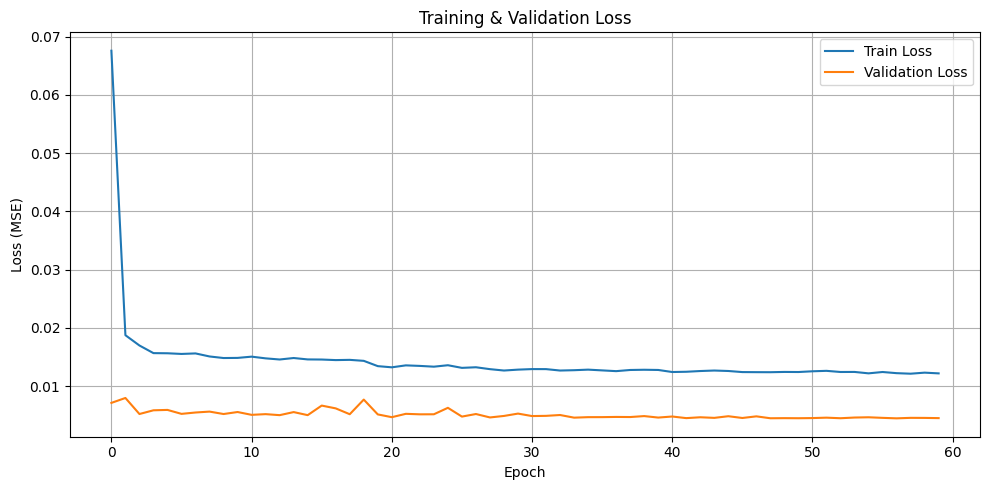

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(t_l2, label='Train Loss')
plt.plot(v_l2, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### Metrics

In [37]:
with torch.no_grad():
    model2.eval()
    batch_size = 256
    preds = []
    for i in range(0, len(X_test_tensor), batch_size):
        batch= X_test_tensor[i:i+batch_size].to(device)
        preds.append(model2(batch).cpu().numpy())
    y_pred_test = np.concatenate(preds, axis=0)
    y_test_np = y_test_tensor.cpu().numpy()
    y_pred_test_inv = scaler.inverse_transform(y_pred_test)
    y_test_inv = scaler.inverse_transform(y_test)
mse = mean_squared_error(y_test_inv, y_pred_test_inv)
mae = mean_absolute_error(y_test_inv, y_pred_test_inv)
mape = mean_absolute_percentage_error(y_test_inv, y_pred_test_inv)
print(f"Test MSE: {mse:.2f}, MAE: {mae:.2f},MAPE: {mape:.2%}")

Test MSE: 0.33, MAE: 0.40,MAPE: 10.47%


##### Forecasting)

In [38]:
model2.eval()
last_sequence_2 = train_scaled[-sequence_length:].reshape(1, sequence_length, 1)
forecast_scaled_2 = []

for _ in range(n_forecast):
    next_pred = model2(torch.tensor(last_sequence_2, dtype=torch.float32).to(device)).cpu().detach().numpy()
    forecast_scaled_2.append(next_pred[0, 0])
    last_sequence_2 = np.append(last_sequence_2[:, 1:, :], [[[next_pred[0, 0]]]], axis=1)


# Inverse scale forecast
forecast_2 = scaler.inverse_transform(np.array(forecast_scaled_2).reshape(-1, 1))

# Build forecast time index
forecast_index_2 = val_df.index[:n_forecast]

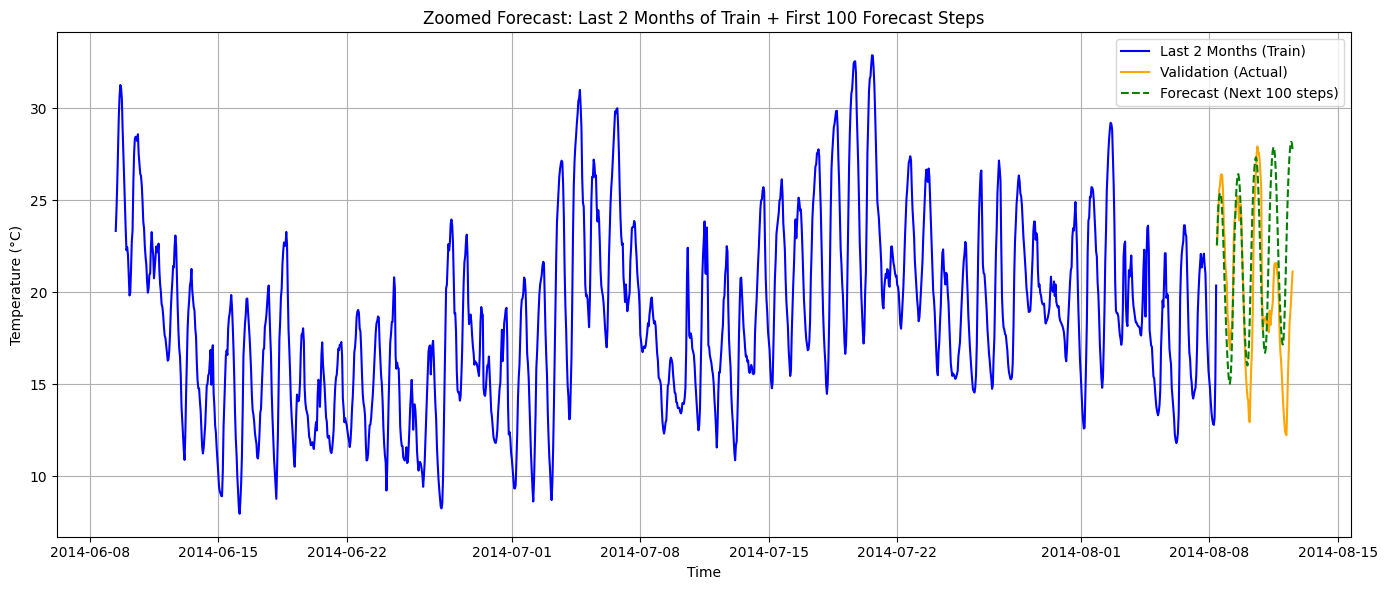

In [39]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(last_2_months.index, last_2_months['T (degC)'], label='Last 2 Months (Train)', color='blue')
plt.plot(val_plot.index, val_plot['T (degC)'], color='orange', label='Validation (Actual)')
plt.plot(forecast_index_2, forecast_2, label='Forecast (Next 100 steps)', color='green',linestyle='--')

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Zoomed Forecast: Last 2 Months of Train + First 100 Forecast Steps")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

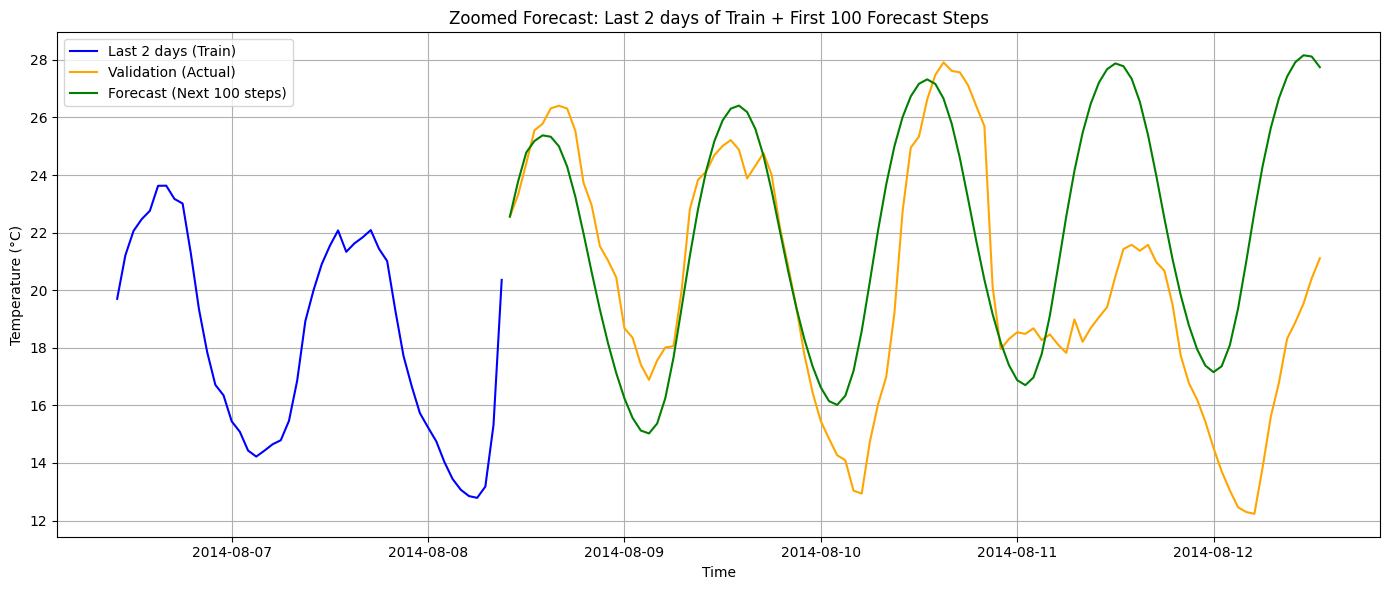

In [40]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(last_2_days.index, last_2_days['T (degC)'], label='Last 2 days (Train)', color='blue')
plt.plot(val_plot.index, val_plot['T (degC)'], color='orange', label='Validation (Actual)')
plt.plot(forecast_index_2, forecast_2, label='Forecast (Next 100 steps)', color='green')

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Zoomed Forecast: Last 2 days of Train + First 100 Forecast Steps")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()